In [1]:
import anndata
import torch
import stPlus

import squidpy as sq
import numpy as np
import scanpy as sc
import pandas as pd

from scipy import sparse
from sklearn.model_selection import KFold
from transpa.eval_util import calc_corr
from transpa.util import expTransImp, leiden_cluster, compute_autocorr, expLocImp
from benchmark import SpaGE_impute, Tangram_impute
import warnings
from sklearn.preprocessing import MinMaxScaler
torch.autograd.detect_anomaly()
warnings.filterwarnings('ignore')

seed = 10
device = torch.device("cuda:2") if torch.cuda.is_available() else torch.device("cpu")

In [2]:
spa_counts = np.load('../../data/ST/Starmap/visual_1020/20180505_BY3_1kgenes/cell_barcode_count.npy')
genes = pd.read_csv("../../data/ST/Starmap/visual_1020/20180505_BY3_1kgenes/genes.csv", header=None).iloc[:,0]
coordinates = pd.read_csv("../../data/ST/Starmap/visual_1020/20180505_BY3_1kgenes/centroids.tsv", header=None, sep='\t')

spa_adata = anndata.AnnData(spa_counts)
sc.pp.normalize_total(spa_adata)
sc.pp.log1p(spa_adata)
spa_adata.obs['X'] = coordinates.iloc[:, 0].values
spa_adata.obs['Y'] = coordinates.iloc[:, 1].values
spa_adata.var_names = genes

scrna_adata = sc.read("../../data/scRNAseq/Allen_VISp/mouse_VISp_2018-06-14_exon-matrix.csv").T
genes = pd.read_csv("../../data/scRNAseq/Allen_VISp/mouse_VISp_2018-06-14_genes-rows.csv", header=0,sep=',')
VISp_meta = pd.read_csv("../../data/scRNAseq/Allen_VISp/mouse_VISp_2018-06-14_samples-columns.csv", header=0,sep=',')
scrna_adata.obs = VISp_meta
scrna_adata.var_names = genes.gene_symbol

sc.pp.filter_genes(scrna_adata, min_cells=10)
scrna_adata = scrna_adata[(scrna_adata.obs['class'] != 'No Class') & (scrna_adata.obs['class'] != 'Low Quality')]
sc.pp.normalize_total(scrna_adata)
sc.pp.log1p(scrna_adata)

scrna_adata, spa_adata


(AnnData object with n_obs × n_vars = 14249 × 34617
     obs: 'sample_name', 'sample_id', 'sample_type', 'organism', 'donor', 'sex', 'age_days', 'eye_condition', 'genotype', 'driver_lines', 'reporter_lines', 'brain_hemisphere', 'brain_region', 'brain_subregion', 'injection_label_direction', 'injection_primary', 'injection_secondary', 'injection_tract', 'injection_material', 'injection_exclusion_criterion', 'facs_date', 'facs_container', 'facs_sort_criteria', 'rna_amplification_set', 'library_prep_set', 'library_prep_avg_size_bp', 'seq_name', 'seq_tube', 'seq_batch', 'total_reads', 'percent_exon_reads', 'percent_intron_reads', 'percent_intergenic_reads', 'percent_rrna_reads', 'percent_mt_exon_reads', 'percent_reads_unique', 'percent_synth_reads', 'percent_ecoli_reads', 'percent_aligned_reads_total', 'complexity_cg', 'genes_detected_cpm_criterion', 'genes_detected_fpkm_criterion', 'tdt_cpm', 'gfp_cpm', 'class', 'subclass', 'cluster', 'confusion_score', 'cluster_correlation', 'core_interm

In [3]:
raw_spatial_df  = pd.DataFrame(spa_adata.X, columns=spa_adata.var_names)
raw_scrna_df    = pd.DataFrame(scrna_adata.X, columns=scrna_adata.var_names)

raw_shared_gene = np.intersect1d(raw_spatial_df.columns, raw_scrna_df.columns)
valid_genes = np.intersect1d(spa_adata.var_names, scrna_adata.var_names)
raw_spatial_df.shape, raw_scrna_df.shape, raw_shared_gene.shape

((1549, 1020), (14249, 34617), (994,))

In [4]:
spa_adata.obsm['spatial'] = np.hstack([spa_adata.obs.X.values.reshape(-1,1), spa_adata.obs.Y.values.reshape(-1,1)])
spa_adata.obsm['spatial'] = MinMaxScaler().fit_transform(spa_adata.obsm['spatial'])
spa_adata, scrna_adata

(AnnData object with n_obs × n_vars = 1549 × 1020
     obs: 'X', 'Y'
     uns: 'log1p'
     obsm: 'spatial',
 AnnData object with n_obs × n_vars = 14249 × 34617
     obs: 'sample_name', 'sample_id', 'sample_type', 'organism', 'donor', 'sex', 'age_days', 'eye_condition', 'genotype', 'driver_lines', 'reporter_lines', 'brain_hemisphere', 'brain_region', 'brain_subregion', 'injection_label_direction', 'injection_primary', 'injection_secondary', 'injection_tract', 'injection_material', 'injection_exclusion_criterion', 'facs_date', 'facs_container', 'facs_sort_criteria', 'rna_amplification_set', 'library_prep_set', 'library_prep_avg_size_bp', 'seq_name', 'seq_tube', 'seq_batch', 'total_reads', 'percent_exon_reads', 'percent_intron_reads', 'percent_intergenic_reads', 'percent_rrna_reads', 'percent_mt_exon_reads', 'percent_reads_unique', 'percent_synth_reads', 'percent_ecoli_reads', 'percent_aligned_reads_total', 'complexity_cg', 'genes_detected_cpm_criterion', 'genes_detected_fpkm_criterion',

In [5]:
sc_expr = sparse.coo_matrix(raw_scrna_df[raw_shared_gene].values)
sp_expr = raw_spatial_df[raw_shared_gene].values
loc     = spa_adata.obsm['spatial']
sc_loc = expLocImp(sc_expr, 
            sp_expr,
            loc,
            n_neighbors=4,
            l_kernel=2,
            autocorr_method='moranI',
            mapping_lowdim=128,
            lr=1e-4, weight_decay=1e-3, n_epochs=2500,
            device=device,
            seed=seed
            ) 

scrna_adata.obsm["sc_spatial"] = sc_loc # MinMaxScaler().fit_transform(sc_loc)
         

2022-12-24 21:14:47,751 - harmonypy - INFO - Iteration 1 of 10
2022-12-24 21:14:56,481 - harmonypy - INFO - Iteration 2 of 10
2022-12-24 21:15:04,826 - harmonypy - INFO - Iteration 3 of 10
2022-12-24 21:15:12,621 - harmonypy - INFO - Converged after 3 iterations
[LocImp] Epoch: 2500/2500, loss: 0.048535: 100%|██████████| 2500/2500 [02:42<00:00, 15.35it/s]


In [6]:
scrna_adata_sub = scrna_adata[:, valid_genes].copy()
scrna_adata_sub.X = scrna_adata_sub.X
sq.gr.spatial_neighbors(scrna_adata_sub,  spatial_key="sc_spatial", key_added="sc_spatial")
sq.gr.spatial_autocorr(
    scrna_adata_sub,
    connectivity_key="sc_spatial_connectivities",
    mode="moran",
    # n_perms=100,
    n_jobs=10,
)

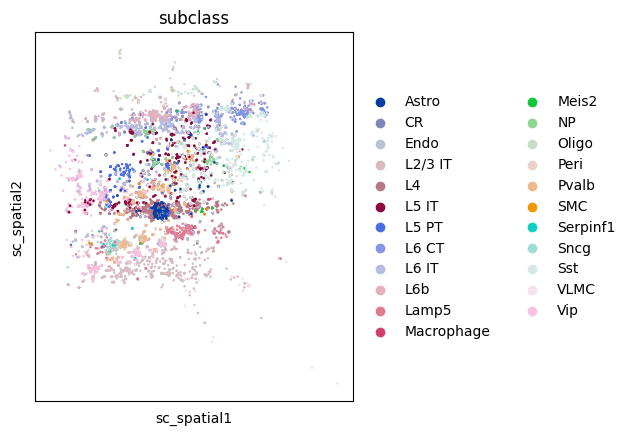

In [7]:
sc.pl.spatial(scrna_adata_sub, basis="sc_spatial", color="subclass", spot_size=0.01)

(array([6.710e+02, 1.033e+03, 2.378e+03, 2.871e+03, 4.108e+03, 1.711e+03,
       1.140e+03, 3.280e+02, 7.000e+00, 2.000e+00]), array([0.05137219, 0.16735937, 0.28334656, 0.39933375, 0.5153209 ,
       0.6313081 , 0.74729526, 0.86328244, 0.9792696 , 1.0952568 ,
       1.211244  ], dtype=float32), <BarContainer object of 10 artists>)


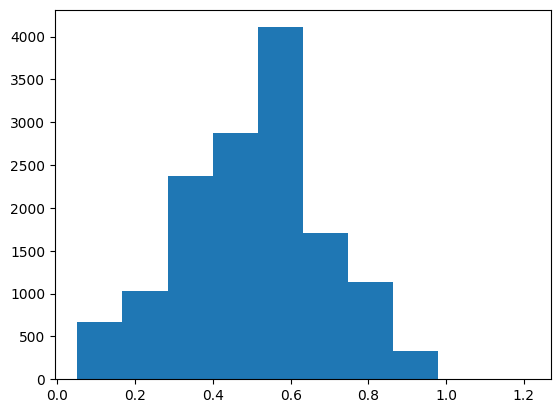

(array([1.700e+01, 1.244e+03, 3.028e+03, 2.619e+03, 3.944e+03, 2.032e+03,
        1.302e+03, 5.600e+01, 5.000e+00, 2.000e+00]),
 array([-0.01444   ,  0.12024128,  0.25492257,  0.38960382,  0.52428514,
         0.6589664 ,  0.79364765,  0.92832893,  1.0630102 ,  1.1976916 ,
         1.3323728 ], dtype=float32),
 <BarContainer object of 10 artists>)

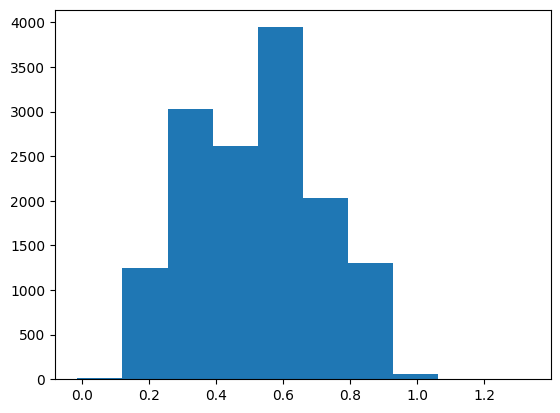

In [8]:
from matplotlib import pyplot as plt
print(plt.hist(sc_loc[:, 0])); plt.show(); plt.hist(sc_loc[:, 1])

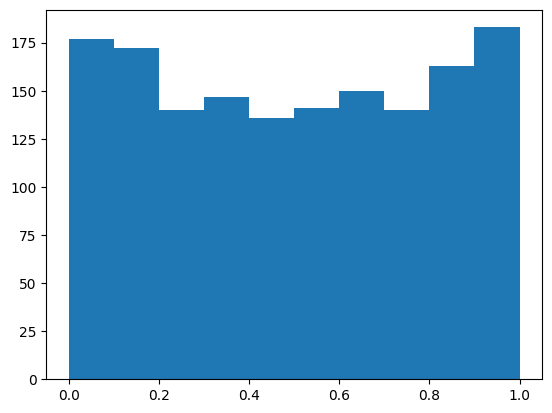

(array([120., 172., 186., 144., 145., 164., 203., 165., 152.,  98.]),
 array([0. , 0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9, 1. ]),
 <BarContainer object of 10 artists>)

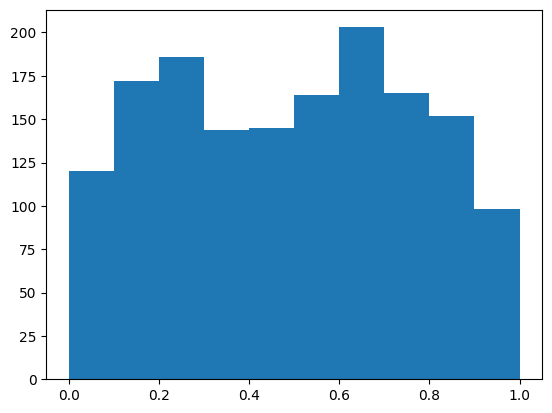

In [9]:
from matplotlib import pyplot as plt
plt.hist(spa_adata.obsm['spatial'][:, 0]); plt.show(); plt.hist(spa_adata.obsm['spatial'][:, 1])

2022-12-24 21:18:24,577 - harmonypy - INFO - Iteration 1 of 10
2022-12-24 21:18:32,609 - harmonypy - INFO - Iteration 2 of 10
2022-12-24 21:18:40,562 - harmonypy - INFO - Iteration 3 of 10
2022-12-24 21:18:48,444 - harmonypy - INFO - Converged after 3 iterations


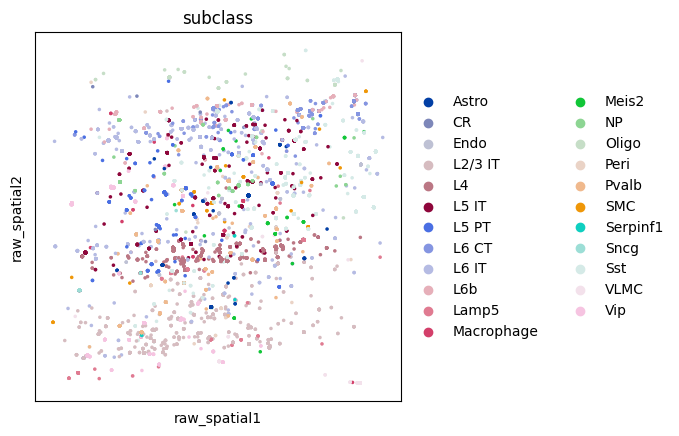

In [10]:
from sklearn.neighbors import  NearestNeighbors
from scipy.special import softmax
spa_adata_sub = spa_adata[:, valid_genes].copy()
K = 2
adata = sc.AnnData(np.vstack([scrna_adata_sub.X, spa_adata_sub.X]))
adata.obs['batch'] = ["a"] * scrna_adata_sub.shape[0] + ['b'] * spa_adata_sub.shape[0]
sc.pp.pca(adata)
sc.external.pp.harmony_integrate(adata, 'batch')

emb_sc = adata.obsm['X_pca_harmony'][:sc_expr.shape[0], :]
emb_sp = adata.obsm['X_pca_harmony'][sc_expr.shape[0]:, :]
nn = NearestNeighbors(n_neighbors=K, metric='cosine', n_jobs=20)
nn.fit(emb_sp)
dists, nbs = nn.kneighbors(emb_sc, K, True)
sc_loc = np.expand_dims(softmax(-dists, axis=-1),1) @ loc[nbs]

scrna_adata_sub.obsm["raw_spatial"] = sc_loc.squeeze() # MinMaxScaler().fit_transform(sc_loc)
sc.pl.spatial(scrna_adata_sub, basis="raw_spatial", color="subclass", spot_size=0.01)


In [11]:
sq.gr.spatial_neighbors(spa_adata_sub,  spatial_key="spatial", key_added="spatial")
sq.gr.spatial_autocorr(
    spa_adata_sub,
    connectivity_key="spatial_connectivities",
    mode="moran",
    # n_perms=100,
    n_jobs=10,
)
spa_adata_sub.uns["moranI"]

,I,pval_norm,var_norm,pval_norm_fdr_bh
Mbp,0.649910,0.000000,0.000216,0.000000
Mobp,0.617992,0.000000,0.000216,0.000000
Plp1,0.540543,0.000000,0.000216,0.000000
Camk2n1,0.471690,0.000000,0.000216,0.000000
Nrgn,0.346898,0.000000,0.000216,0.000000
...,...,...,...,...
Chrna6,-0.015667,0.153296,0.000216,0.211647
Tspan12,-0.017792,0.121586,0.000216,0.177470
Crispld2,-0.021710,0.075818,0.000216,0.122145
Ackr1,-0.022995,0.064105,0.000216,0.106735


In [12]:
sq.gr.spatial_neighbors(scrna_adata_sub,  spatial_key="raw_spatial", key_added="raw_spatial")
sq.gr.spatial_autocorr(
    scrna_adata_sub,
    connectivity_key="raw_spatial_connectivities",
    mode="moran",
    # n_perms=100,
    n_jobs=10,
)
scrna_adata_sub.uns["moranI"].loc[valid_genes]

,I,pval_norm,var_norm,pval_norm_fdr_bh
1110008F13Rik,0.162320,0.0,0.000025,0.0
1110008P14Rik,0.666625,0.0,0.000025,0.0
1700019D03Rik,0.337829,0.0,0.000025,0.0
1700086L19Rik,0.446207,0.0,0.000025,0.0
2810468N07Rik,0.304668,0.0,0.000025,0.0
...,...,...,...,...
Zfp637,0.204880,0.0,0.000025,0.0
Zmat4,0.593403,0.0,0.000025,0.0
Zmym1,0.189881,0.0,0.000025,0.0
Znhit3,0.352487,0.0,0.000025,0.0


In [13]:
scrna_adata_cp = scrna_adata_sub.copy()
sq.gr.spatial_neighbors(scrna_adata_cp,  spatial_key="sc_spatial", key_added="sc_spatial")
sq.gr.spatial_autocorr(
    scrna_adata_cp,
    connectivity_key="sc_spatial_connectivities",
    mode="moran",
    # n_perms=100,
    n_jobs=10,
)
scrna_adata_cp.uns["moranI"].loc[valid_genes]

,I,pval_norm,var_norm,pval_norm_fdr_bh
1110008F13Rik,0.058762,0.0,0.000026,0.0
1110008P14Rik,0.341873,0.0,0.000026,0.0
1700019D03Rik,0.216459,0.0,0.000026,0.0
1700086L19Rik,0.258712,0.0,0.000026,0.0
2810468N07Rik,0.208189,0.0,0.000026,0.0
...,...,...,...,...
Zfp637,0.073730,0.0,0.000026,0.0
Zmat4,0.384844,0.0,0.000026,0.0
Zmym1,0.103732,0.0,0.000026,0.0
Znhit3,0.117817,0.0,0.000026,0.0


In [14]:
from sklearn.metrics import mean_squared_error
print(mean_squared_error(spa_adata_sub.uns['moranI'].I, scrna_adata_sub.uns['moranI'].loc[spa_adata_sub.uns['moranI'].index].I))
print(mean_squared_error(spa_adata_sub.uns['moranI'].I, scrna_adata_cp.uns['moranI'].loc[spa_adata_sub.uns['moranI'].index].I))

0.1873591431236904
0.0579338719391219


I                   9.222292e-02
pval_norm           1.297373e-10
var_norm            2.158422e-04
pval_norm_fdr_bh    1.535225e-09
Name: Fos, dtype: float64
AnnData object with n_obs × n_vars = 1549 × 1
    obsm: 'spatial'


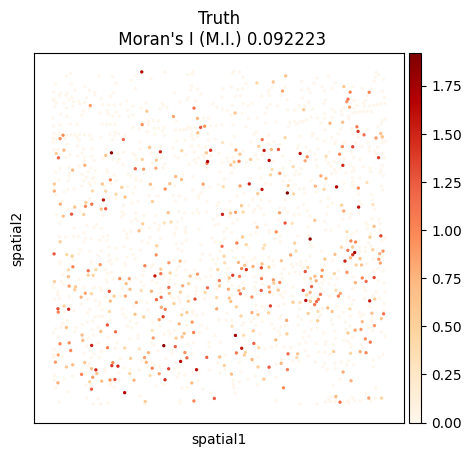

I                   0.355588
pval_norm           0.000000
var_norm            0.000025
pval_norm_fdr_bh    0.000000
Name: Fos, dtype: float64
AnnData object with n_obs × n_vars = 14249 × 1
    obsm: 'sc_spatial', 'raw_spatial'


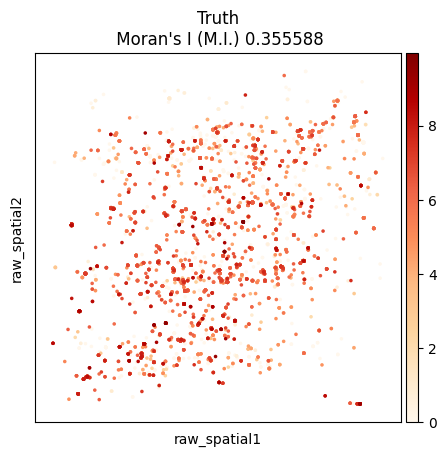

I                   0.192005
pval_norm           0.000000
var_norm            0.000026
pval_norm_fdr_bh    0.000000
Name: Fos, dtype: float64
AnnData object with n_obs × n_vars = 14249 × 1
    obsm: 'sc_spatial', 'raw_spatial'


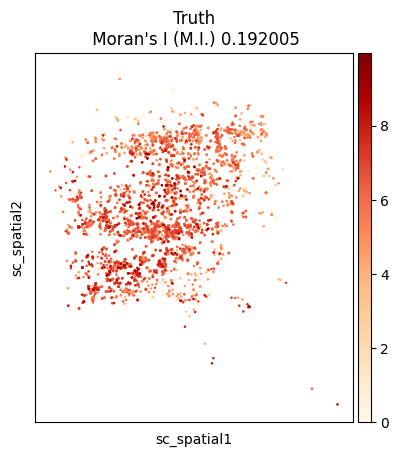

In [15]:
def plot(gene, spa_adata, spa_key):
    exprs = [spa_adata[:, gene].X.toarray().flatten()]
    titles = [f"Truth\n Moran's I (M.I.) {spa_adata.uns['moranI'].loc[gene].I:.6f}"]
    # sc.pl.spatial(spa_adata, color=[gene], spot_size=0.1, title='Truth')
    print(spa_adata.uns['moranI'].loc[gene])
    
    tmp_adata = sc.AnnData(np.array(exprs).T)
    tmp_adata.obsm = spa_adata.obsm
    tmp_adata.var_names = titles
    
    print(tmp_adata)
    sc.pl.spatial(tmp_adata, color=titles, basis=spa_key, spot_size=0.01, title=titles, color_map='OrRd')
plot("Fos", spa_adata_sub, spa_key='spatial')
plot("Fos", scrna_adata_sub, spa_key='raw_spatial')
plot("Fos", scrna_adata_cp, spa_key='sc_spatial')

I                   0.054533
pval_norm           0.000086
var_norm            0.000216
pval_norm_fdr_bh    0.000389
Name: Sema3e, dtype: float64
AnnData object with n_obs × n_vars = 1549 × 1
    obsm: 'spatial'


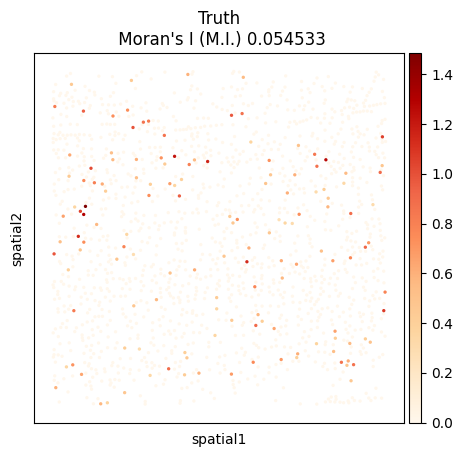

I                   0.595103
pval_norm           0.000000
var_norm            0.000025
pval_norm_fdr_bh    0.000000
Name: Sema3e, dtype: float64
AnnData object with n_obs × n_vars = 14249 × 1
    obsm: 'sc_spatial', 'raw_spatial'


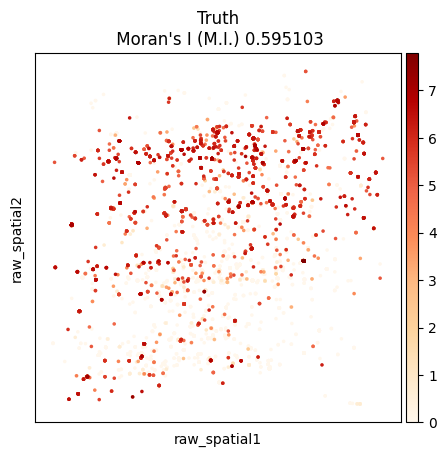

I                   0.441987
pval_norm           0.000000
var_norm            0.000026
pval_norm_fdr_bh    0.000000
Name: Sema3e, dtype: float64
AnnData object with n_obs × n_vars = 14249 × 1
    obsm: 'sc_spatial', 'raw_spatial'


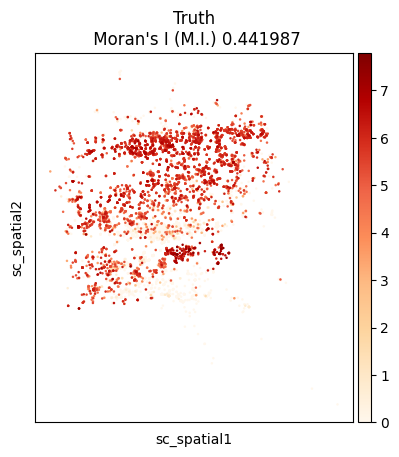

In [16]:
plot("Sema3e", spa_adata_sub, spa_key='spatial')
plot("Sema3e", scrna_adata_sub, spa_key='raw_spatial')
plot("Sema3e", scrna_adata_cp, spa_key='sc_spatial')

I                   0.044583
pval_norm           0.001040
var_norm            0.000216
pval_norm_fdr_bh    0.003346
Name: Egr2, dtype: float64
AnnData object with n_obs × n_vars = 1549 × 1
    obsm: 'spatial'


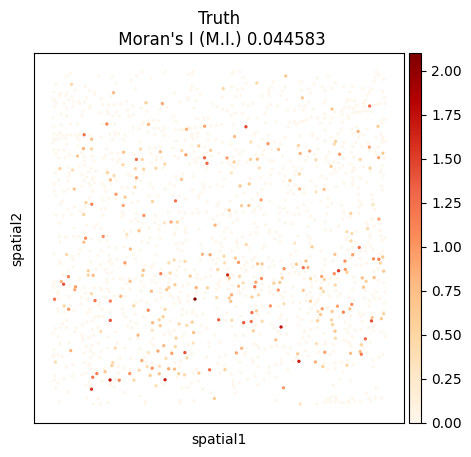

I                   0.388710
pval_norm           0.000000
var_norm            0.000025
pval_norm_fdr_bh    0.000000
Name: Egr2, dtype: float64
AnnData object with n_obs × n_vars = 14249 × 1
    obsm: 'sc_spatial', 'raw_spatial'


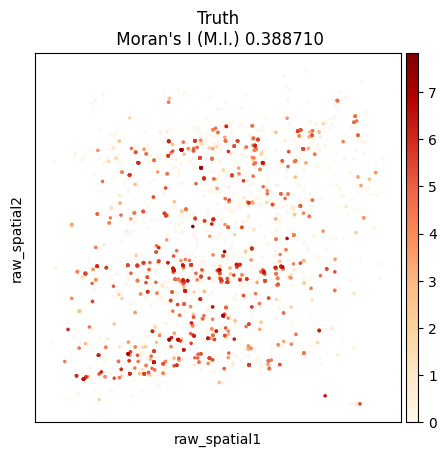

I                   0.166973
pval_norm           0.000000
var_norm            0.000026
pval_norm_fdr_bh    0.000000
Name: Egr2, dtype: float64
AnnData object with n_obs × n_vars = 14249 × 1
    obsm: 'sc_spatial', 'raw_spatial'


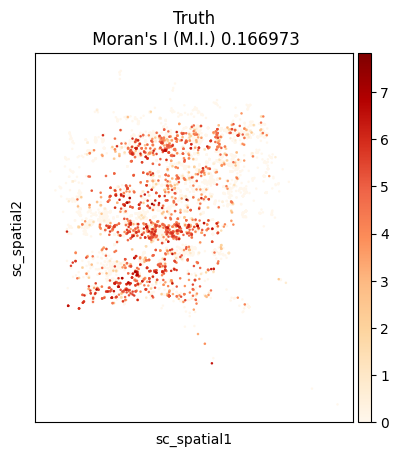

In [17]:
plot("Egr2", spa_adata_sub, spa_key='spatial')
plot("Egr2", scrna_adata_sub, spa_key='raw_spatial')
plot("Egr2", scrna_adata_cp, spa_key='sc_spatial')

I                   0.269582
pval_norm           0.000000
var_norm            0.000216
pval_norm_fdr_bh    0.000000
Name: Egr1, dtype: float64
AnnData object with n_obs × n_vars = 1549 × 1
    obsm: 'spatial'


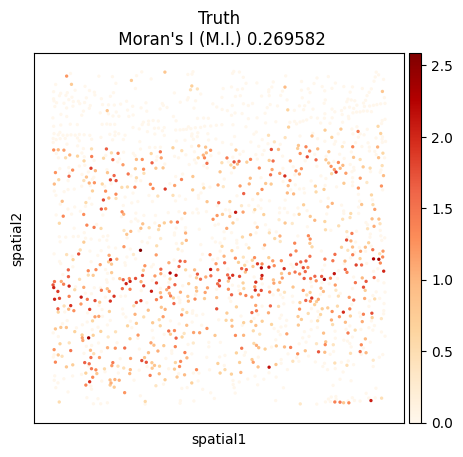

I                   0.619135
pval_norm           0.000000
var_norm            0.000025
pval_norm_fdr_bh    0.000000
Name: Egr1, dtype: float64
AnnData object with n_obs × n_vars = 14249 × 1
    obsm: 'sc_spatial', 'raw_spatial'


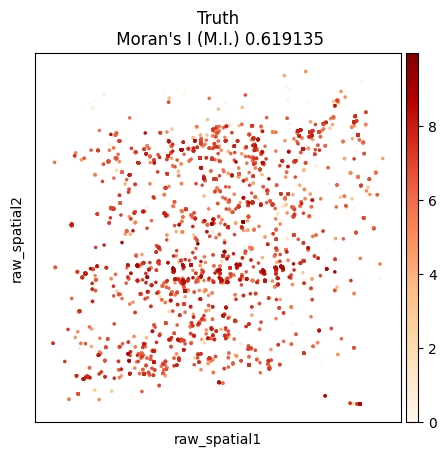

I                   0.366971
pval_norm           0.000000
var_norm            0.000026
pval_norm_fdr_bh    0.000000
Name: Egr1, dtype: float64
AnnData object with n_obs × n_vars = 14249 × 1
    obsm: 'sc_spatial', 'raw_spatial'


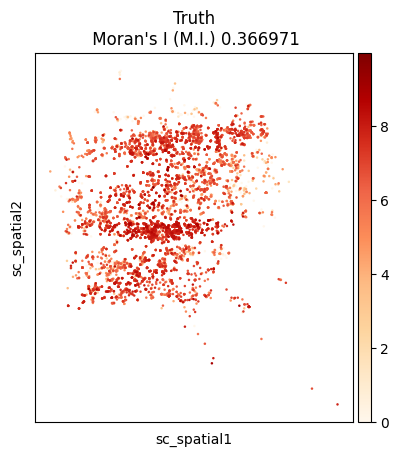

In [18]:
plot("Egr1", spa_adata_sub, spa_key='spatial')
plot("Egr1", scrna_adata_sub, spa_key='raw_spatial')
plot("Egr1", scrna_adata_cp, spa_key='sc_spatial')